In [ ]:
# Import necessary libraries
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import dates as mdates
import copernicusmarine
import warnings
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Ensure output folder exists for all exported figures
FIG_DIR = Path("Figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
ds_mhw2016_2016 = xr.open_dataset("Data/mhw2016JFM_sst_2016.nc")

c:\Users\natal\repos\OceanCourses\.ocean\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# -----------------------------------------------------------------
# Load datasets for analysis of MHW2016 -> years from 2013 to 2019
# -----------------------------------------------------------------

# Load sea surface temperature (SST) datasets for MHW2016 event
ds_mhw2016_sst_2016 = xr.open_dataset("Data/mhw2016JFM_sst_2016.nc")
ds_mhw2016_sst_2013 = xr.open_dataset("Data/mhw2016JFM_sst_2013.nc")
ds_mhw2016_sst_2014 = xr.open_dataset("Data/mhw2016JFM_sst_2014.nc")
ds_mhw2016_sst_2015 = xr.open_dataset("Data/mhw2016JFM_sst_2015.nc")
ds_mhw2016_sst_2017 = xr.open_dataset("Data/mhw2016JFM_sst_2017.nc")
ds_mhw2016_sst_2018 = xr.open_dataset("Data/mhw2016JFM_sst_2018.nc")
ds_mhw2016_sst_2019 = xr.open_dataset("Data/mhw2016JFM_sst_2019.nc")

# Load total cloud cover (TCC) datasets for MHW2016 event
ds_mhw2016_tcc_2016 = xr.open_dataset("Data/mhw2016JFM_tcc_2016.nc")
ds_mhw2016_tcc_2013 = xr.open_dataset("Data/mhw2016JFM_tcc_2013.nc")
ds_mhw2016_tcc_2014 = xr.open_dataset("Data/mhw2016JFM_tcc_2014.nc")
ds_mhw2016_tcc_2015 = xr.open_dataset("Data/mhw2016JFM_tcc_2015.nc")
ds_mhw2016_tcc_2017 = xr.open_dataset("Data/mhw2016JFM_tcc_2017.nc")
ds_mhw2016_tcc_2018 = xr.open_dataset("Data/mhw2016JFM_tcc_2018.nc")
ds_mhw2016_tcc_2019 = xr.open_dataset("Data/mhw2016JFM_tcc_2019.nc")    

# Load 100m u wind component datasets for MHW2016 event
ds_mhw2016_uwind_2016 = xr.open_dataset("Data/mhw2016JFM_uwind_2016.nc")
ds_mhw2016_uwind_2013 = xr.open_dataset("Data/mhw2016JFM_uwind_2013.nc")
ds_mhw2016_uwind_2014 = xr.open_dataset("Data/mhw2016JFM_uwind_2014.nc")
ds_mhw2016_uwind_2015 = xr.open_dataset("Data/mhw2016JFM_uwind_2015.nc")
ds_mhw2016_uwind_2017 = xr.open_dataset("Data/mhw2016JFM_uwind_2017.nc")
ds_mhw2016_uwind_2018 = xr.open_dataset("Data/mhw2016JFM_uwind_2018.nc")
ds_mhw2016_uwind_2019 = xr.open_dataset("Data/mhw2016JFM_uwind_2019.nc")

In [ ]:
# Group the datasets into lists for easier processing
sst_datasets_mhw2016 = [ds_mhw2016_sst_2013, ds_mhw2016_sst_2014, ds_mhw2016_sst_2015, ds_mhw2016_sst_2016, ds_mhw2016_sst_2017, ds_mhw2016_sst_2018, ds_mhw2016_sst_2019]
tcc_datasets_mhw2016 = [ds_mhw2016_tcc_2013, ds_mhw2016_tcc_2014, ds_mhw2016_tcc_2015, ds_mhw2016_tcc_2016, ds_mhw2016_tcc_2017, ds_mhw2016_tcc_2018, ds_mhw2016_tcc_2019]
uwind_datasets_mhw2016 = [ds_mhw2016_uwind_2013, ds_mhw2016_uwind_2014, ds_mhw2016_uwind_2015, ds_mhw2016_uwind_2016, ds_mhw2016_uwind_2017, ds_mhw2016_uwind_2018, ds_mhw2016_uwind_2019]

In [ ]:
# Variable name mapping with units for clearer graph titles/labels
var_names = {
    'analysed_sst': 'Sea Surface Temperature (°C)',
    'tcc': 'Total Cloud Cover (%)',
    'u100': '100m U Component of Wind (m/s)',
    'v100': '100m V Component of Wind (m/s)'
}

# Convert temperature from Kelvin to degree Celsius when needed in all ds datasets
for ds in [ds_mhw2016_sst_2016]:
    analysed_sst_mean = float(ds['analysed_sst'].mean(skipna=True).values)
    if analysed_sst_mean > 100.0:
        ds['analysed_sst'] = ds['analysed_sst'] - 273.15
        ds['analysed_sst'].attrs['units'] = 'degC'

KeyError: "No variable named 'analysed_sst'. Variables on the dataset include ['u100', 'latitude', 'longitude', 'valid_time', 'number']"

In [14]:
def plot_mean_std_maps(ds,variable, years_range, depth_sel=None):
    """ Compute and plot time-mean and time-std maps for one variable."""

    # Get full variable name and select the variable
    var_full_name = var_names.get(variable, variable)
    da = ds[variable]

    # # Depth handling
    # if 'depth' in da.dims:
    #     if depth_sel is None:
    #         depth_sel = float(da['depth'].isel(depth=0).values)
    #     da = da.sel(depth=depth_sel, method='nearest')
    #     print(f"{var_full_name}: using depth={float(da['depth'].values):.2f}")

    # Compute time mean and std, skip the NaN values
    da_mean = da.mean(dim='time', skipna=True)
    da_std = da.std(dim='time', skipna=True)

    fig, axes = plt.subplots(2, 1, figsize=(8, 8))

    # Plot the mean graph
    da_mean.plot(
        ax=axes[0],
        cmap='viridis',
        cbar_kwargs={'label': f'{var_full_name}'})
    
    axes[0].set_title(f"{var_full_name}: Time Mean {years_range}")
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')

    # Plot the STD graph
    da_std.plot(
        ax=axes[1],
        cmap='magma',
        cbar_kwargs={'label': f'{var_full_name}'})
    
    axes[1].set_title(f"{var_full_name}: Time Std {years_range}")
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')

    plt.tight_layout()
    # Save first, then show, to avoid blank exported images in some backends
    plt.savefig(FIG_DIR / f"Variable_Map_{variable}_{years_range}.png", dpi=300, bbox_inches='tight')
    plt.show()



def plot_mean_std_maps_era5(ds, variable, years_range, region=None):
    """Compute and plot time-mean and time-std maps for ERA5 using the SST region box."""

    if region is None:
        region = {
            "minimum_longitude": -75.0,
            "maximum_longitude": -4.0,
            "minimum_latitude": 35.0,
            "maximum_latitude": 55.0,
        }

    lon_min = region['minimum_longitude']
    lon_max = region['maximum_longitude']
    lat_min = region['minimum_latitude']
    lat_max = region['maximum_latitude']

    var_full_name = var_names.get(variable, variable)
    da = ds[variable]

    # ERA5 commonly stores valid_time as temporal axis; keep latitude/longitude for mapping.
    temporal_dim = 'valid_time' if 'valid_time' in da.dims else 'time'
    reduce_non_spatial = [d for d in da.dims if d not in [temporal_dim, 'latitude', 'longitude']]
    if reduce_non_spatial:
        da = da.mean(dim=reduce_non_spatial, skipna=True)

    # Detect ERA5 files where coordinate labels are swapped.
    lon_range = (float(np.nanmin(da['longitude'].values)), float(np.nanmax(da['longitude'].values)))
    lat_range = (float(np.nanmin(da['latitude'].values)), float(np.nanmax(da['latitude'].values)))

    def _overlap_span(a_min, a_max, b_min, b_max):
        lo_a, hi_a = min(a_min, a_max), max(a_min, a_max)
        lo_b, hi_b = min(b_min, b_max), max(b_min, b_max)
        return max(0.0, min(hi_a, hi_b) - max(lo_a, lo_b))

    lon_span_with_lon_box = _overlap_span(lon_range[0], lon_range[1], lon_min, lon_max)
    lat_span_with_lon_box = _overlap_span(lat_range[0], lat_range[1], lon_min, lon_max)
    lon_span_with_lat_box = _overlap_span(lon_range[0], lon_range[1], lat_min, lat_max)

    # If longitude only touches the lon box (e.g., overlap near 0) but clearly matches lat box, swap labels.
    if lon_span_with_lon_box < 5.0 and lat_span_with_lon_box > 5.0 and lon_span_with_lat_box > 5.0:
        da = da.rename({'longitude': 'latitude', 'latitude': 'longitude'})

    # Convert longitude from 0..360 to -180..180 so region bounds like -80..0 work directly.
    lon_vals = da['longitude'].values
    if float(np.nanmax(lon_vals)) > 180:
        da = da.assign_coords(longitude=(((da['longitude'] + 180) % 360) - 180)).sortby('longitude')

    # Build robust latitude and longitude slices for either ascending or descending coordinates.
    lat_vals = da['latitude'].values
    if lat_vals[0] <= lat_vals[-1]:
        lat_slice = slice(lat_min, lat_max)
    else:
        lat_slice = slice(lat_max, lat_min)

    lon_vals = da['longitude'].values
    if lon_vals[0] <= lon_vals[-1]:
        lon_slice = slice(lon_min, lon_max)
    else:
        lon_slice = slice(lon_max, lon_min)

    # Apply the same map box used for SST.
    da_box = da.sel(longitude=lon_slice, latitude=lat_slice)

    if da_box.sizes.get('longitude', 0) == 0 or da_box.sizes.get('latitude', 0) == 0:
        lon_cov = (float(np.nanmin(da['longitude'].values)), float(np.nanmax(da['longitude'].values)))
        lat_cov = (float(np.nanmin(da['latitude'].values)), float(np.nanmax(da['latitude'].values)))
        print(
            f"No ERA5 data inside selected box lon [{lon_min}, {lon_max}], lat [{lat_min}, {lat_max}]. "
            f"Dataset coverage is lon [{lon_cov[0]:.2f}, {lon_cov[1]:.2f}], lat [{lat_cov[0]:.2f}, {lat_cov[1]:.2f}]."
        )
        return

    # Ensure numeric dtype for plotting.
    try:
        da_box = da_box.astype(float)
    except Exception:
        print(f"Variable '{variable}' is not numeric after preprocessing; cannot plot.")
        return

    da_mean = da_box.mean(dim=temporal_dim, skipna=True)
    da_std = da_box.std(dim=temporal_dim, skipna=True)

    # Enforce canonical 2D map order for reliable x/y plotting.
    if 'latitude' in da_mean.dims and 'longitude' in da_mean.dims:
        da_mean = da_mean.transpose('latitude', 'longitude')
        da_std = da_std.transpose('latitude', 'longitude')

    # Try geographic map background with coastlines; fallback to plain axes if Cartopy is unavailable.
    try:
        import cartopy.crs as ccrs
        import cartopy.feature as cfeature
        from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
        use_cartopy = True
    except Exception:
        use_cartopy = False

    if use_cartopy:
        fig, axes = plt.subplots(
            2,
            1,
            figsize=(11, 8),
            subplot_kw={'projection': ccrs.PlateCarree()}
        )

        plot_specs = [
            (da_mean, axes[0], 'viridis', f"{var_full_name}: Time Mean {years_range}"),
            (da_std, axes[1], 'magma', f"{var_full_name}: Time Std {years_range}")
        ]

        for field, ax, cmap, title in plot_specs:
            mesh = field.plot(
                ax=ax,
                x='longitude',
                y='latitude',
                transform=ccrs.PlateCarree(),
                cmap=cmap,
                add_colorbar=False
            )

            cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, shrink=0.85)
            cbar.set_label(var_full_name)

            ax.coastlines(resolution='110m', linewidth=0.8, color='black')
            ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='none', alpha=1.0, zorder=3)
            ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor='gray')
            ax.set_title(title)
            ax.set_xlim(lon_min, lon_max)
            ax.set_ylim(lat_min, lat_max)

            # Show numeric lon/lat labels without E/W/N/S suffixes.
            grid = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle='--', color='gray', alpha=0.5)
            grid.top_labels = False
            grid.right_labels = False
            grid.xformatter = LongitudeFormatter(direction_label=False, degree_symbol='')
            grid.yformatter = LatitudeFormatter(direction_label=False, degree_symbol='')

    else:
        fig, axes = plt.subplots(2, 1, figsize=(11, 8))

        da_mean.plot(
            ax=axes[0],
            x='longitude',
            y='latitude',
            cmap='viridis',
            cbar_kwargs={'label': f'{var_full_name}'}
        )
        axes[0].set_title(f"{var_full_name}: Time Mean {years_range}")
        axes[0].set_xlabel('Longitude')
        axes[0].set_ylabel('Latitude')
        axes[0].set_xlim(lon_min, lon_max)
        axes[0].set_ylim(lat_min, lat_max)

        da_std.plot(
            ax=axes[1],
            x='longitude',
            y='latitude',
            cmap='magma',
            cbar_kwargs={'label': f'{var_full_name}'}
        )
        axes[1].set_title(f"{var_full_name}: Time Std {years_range}")
        axes[1].set_xlabel('Longitude')
        axes[1].set_ylabel('Latitude')
        axes[1].set_xlim(lon_min, lon_max)
        axes[1].set_ylim(lat_min, lat_max)

    plt.tight_layout()
    # Save first, then show, to avoid blank exported images in some backends
    plt.savefig(FIG_DIR / f"Variable_Map_{variable}_{years_range}.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

ValueError: Cannot specify both x and y kwargs for line plots.

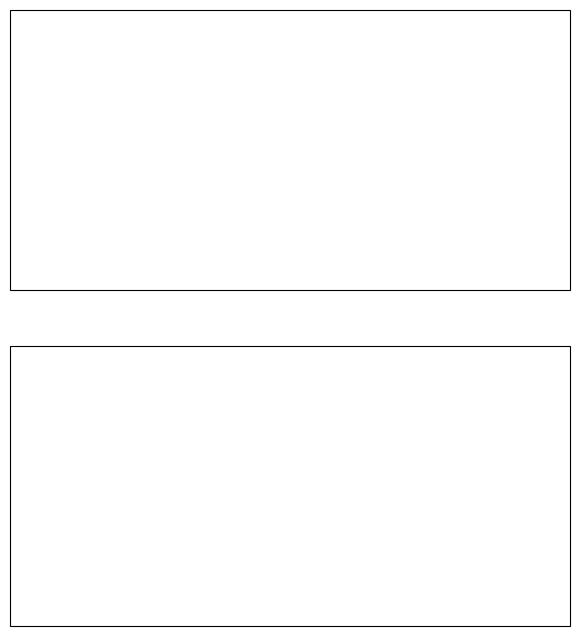

In [21]:
plot_mean_std_maps_era5(ds_mhw2026_tcc_2016, 'tcc', '2016-01-01 to 2016-03-31', region=None)

In [17]:
plot_mean_std_maps_era5(
    ds_mhw2016_uwind_2016,
    '100m_u_component_of_wind',
    '2016-01-01 to 2016-03-31',
    region=None
)

KeyError: "No variable named '100m_u_component_of_wind'. Variables on the dataset include ['u100', 'latitude', 'longitude', 'valid_time', 'number']"